# Проверка практической полезности вероятностных моделей

Ноутбук загружает последний или указанный запуск из отдельного S3-раздела, сравнивает стратегии после комиссии и показывает устойчивость результата к порогу вероятности.

In [1]:
from __future__ import annotations
import io, json, sys
from pathlib import Path
import boto3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'build_price_feature_day.py').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
from build_price_feature_day import make_s3_client

BUCKET = 'binance-data-downloader'
ROOT_PREFIX = 'trading_strategy_experiment'
RUN_ID = None  # Укажите конкретный run_id или оставьте None для latest.json
s3 = make_s3_client()

In [2]:
def read_json(key):
    return json.loads(s3.get_object(Bucket=BUCKET, Key=key)['Body'].read().decode('utf-8'))

def read_parquet(key):
    payload = s3.get_object(Bucket=BUCKET, Key=key)['Body'].read()
    return pd.read_parquet(io.BytesIO(payload))

if RUN_ID is None:
    RUN_ID = read_json(f'{ROOT_PREFIX}/latest.json')['run_id']
RUN_PREFIX = f'{ROOT_PREFIX}/{RUN_ID}'
config = read_json(f'{RUN_PREFIX}/run_config.json')
metrics = read_parquet(f'{RUN_PREFIX}/all_metrics.parquet')
selected = read_parquet(f'{RUN_PREFIX}/selected_evaluation_results.parquet')
display(config)
display(selected.sort_values(['horizon', 'strategy']))

{'run_id': '20260719_134759',
 'created_at_utc': '2026-07-19T13:47:59.060514+00:00',
 'bucket': 'binance-data-downloader',
 'output_prefix': 'trading_strategy_experiment',
 'horizons': [10, 20, 30],
 'fee_per_action': 0.0005,
 'round_trip_fee': 0.001,
 'probability_thresholds': [0.5, 0.55, 0.6, 0.65, 0.7],
 'validation_fraction': 0.5,
 'max_parallel_horizons': 3,
 'threads_per_horizon': 20,
 'maximum_requested_compute_threads': 60,
 'execution_mode': 'target_log_return_proxy',
 'execution_note': 'Target log return is used as the gross holding-period return; no slippage or funding is included.',
 'position_policy': 'one non-overlapping position at a time per horizon',
 'model_specs': {'10': {'horizon': 10,
   'criterion': 'MAE',
   'family_label': 'lasso',
   'n_features': 12,
   'garch_name': 'gjr_garch_1_1'},
  '20': {'horizon': 20,
   'criterion': 'DA',
   'family_label': 'huber',
   'n_features': 33,
   'garch_name': 'gjr_garch_1_1'},
  '30': {'horizon': 30,
   'criterion': 'DA',
  

,strategy,segment,horizon,trades,long_trades,short_trades,gross_total_return,net_total_return,mean_net_return,median_net_return,win_rate,profit_factor,max_drawdown,total_commission,selected_on,probability_threshold
1,catboost_mq_p0.60,evaluation,10,39,39,0,-0.032898,-0.070104,0.002059,0.001239,0.564103,1.126790,-0.471739,0.039,validation,0.60
0,stat_garch_p0.50,evaluation,10,137,121,16,0.166385,0.016783,0.002011,0.001217,0.547445,1.253140,-0.539992,0.137,validation,0.50
5,catboost_mq_p0.65,evaluation,20,32,27,5,0.145177,0.109157,0.005560,0.003718,0.625000,1.395365,-0.315938,0.032,validation,0.65
4,stat_garch_p0.55,evaluation,20,380,343,37,2.691110,1.526943,0.002534,0.001691,0.652632,2.756263,-0.093639,0.380,validation,0.55
3,catboost_mq_p0.65,evaluation,30,32,31,1,0.138560,0.102536,0.010138,0.006811,0.687500,1.572237,-0.430800,0.032,validation,0.65
2,stat_garch_p0.55,evaluation,30,156,156,0,1.819157,1.414228,0.005766,0.004421,0.807692,7.275342,-0.037419,0.156,validation,0.55


## Итог на независимой evaluation-части

,horizon,strategy,trades,net_total_return,max_drawdown,win_rate,profit_factor
7,10,catboost_mq_p0.60,39,-0.070104,-0.471739,0.564103,1.126790
1,10,point_cost_threshold,137,0.016783,-0.539992,0.547445,1.253140
0,10,point_sign,26352,-1.000000,-1.000000,0.351966,0.464498
6,10,stat_garch_p0.50,137,0.016783,-0.539992,0.547445,1.253140
11,20,catboost_mq_p0.65,32,0.109157,-0.315938,0.625000,1.395365
5,20,point_cost_threshold,1127,-0.653550,-0.690879,0.475599,0.798193
4,20,point_sign,13176,-0.999997,-0.999998,0.402778,0.589143
10,20,stat_garch_p0.55,380,1.526943,-0.093639,0.652632,2.756263
9,30,catboost_mq_p0.65,32,0.102536,-0.430800,0.687500,1.572237
3,30,point_cost_threshold,986,-0.614800,-0.671566,0.489858,0.977551


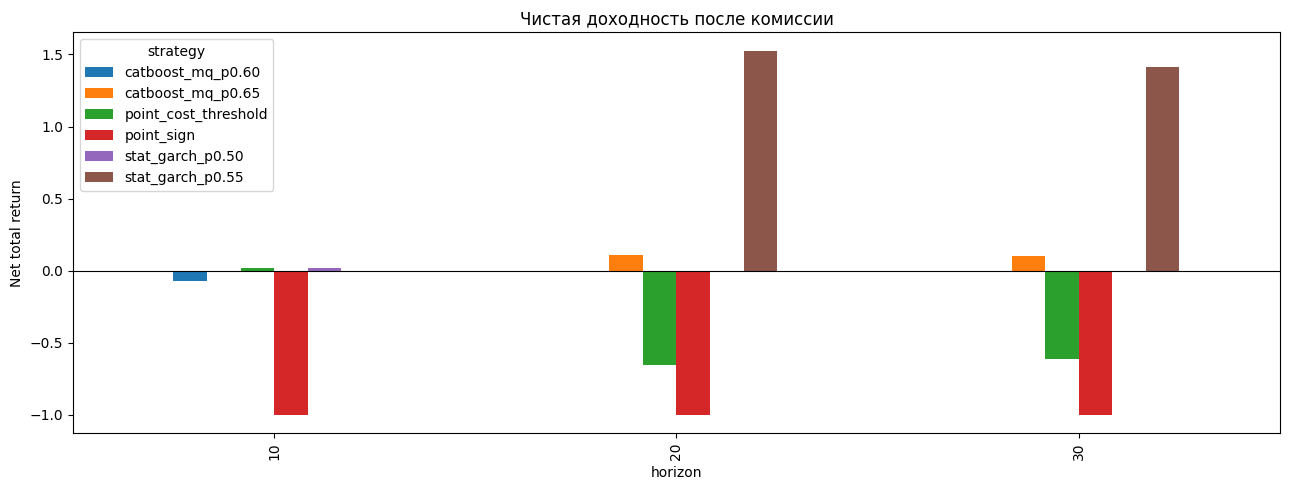

In [3]:
evaluation = metrics.query("segment == 'evaluation'").copy()
point = evaluation[evaluation.strategy.isin(['point_sign', 'point_cost_threshold'])]
comparison = pd.concat([point, selected], ignore_index=True, sort=False)
display(comparison[['horizon','strategy','trades','net_total_return','max_drawdown','win_rate','profit_factor']].sort_values(['horizon','strategy']))

pivot = comparison.pivot(index='horizon', columns='strategy', values='net_total_return')
ax = pivot.plot.bar(figsize=(13, 5), title='Чистая доходность после комиссии')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Net total return')
plt.tight_layout()

## Чувствительность к порогу вероятности

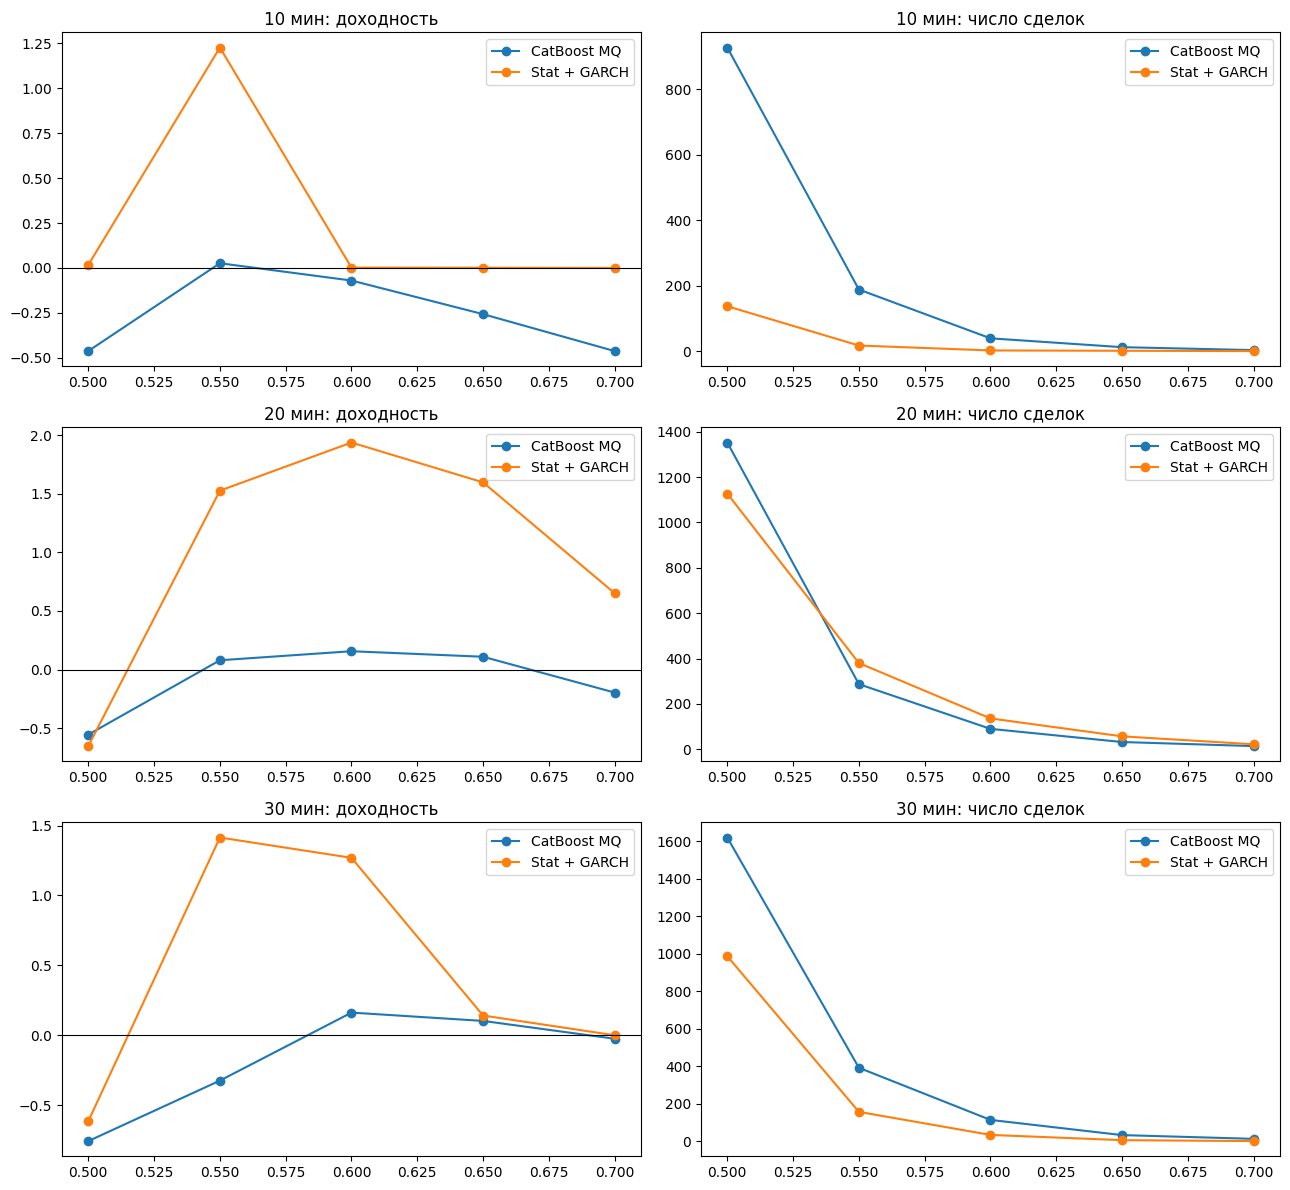

In [4]:
prob = metrics[metrics.strategy.str.contains('_p', regex=False)].copy()
prob['model'] = np.where(prob.strategy.str.startswith('stat_garch'), 'Stat + GARCH', 'CatBoost MQ')
prob['threshold'] = prob.strategy.str.rsplit('_p', n=1).str[-1].astype(float)
fig, axes = plt.subplots(len(config['horizons']), 2, figsize=(13, 4 * len(config['horizons'])), squeeze=False)
for row, horizon in enumerate(config['horizons']):
    part = prob[(prob.horizon == horizon) & (prob.segment == 'evaluation')]
    for model, group in part.groupby('model'):
        group = group.sort_values('threshold')
        axes[row, 0].plot(group.threshold, group.net_total_return, marker='o', label=model)
        axes[row, 1].plot(group.threshold, group.trades, marker='o', label=model)
    axes[row, 0].axhline(0, color='black', linewidth=.8)
    axes[row, 0].set_title(f'{horizon} мин: доходность')
    axes[row, 1].set_title(f'{horizon} мин: число сделок')
    axes[row, 0].legend(); axes[row, 1].legend()
plt.tight_layout()

## Кривые капитала выбранных стратегий

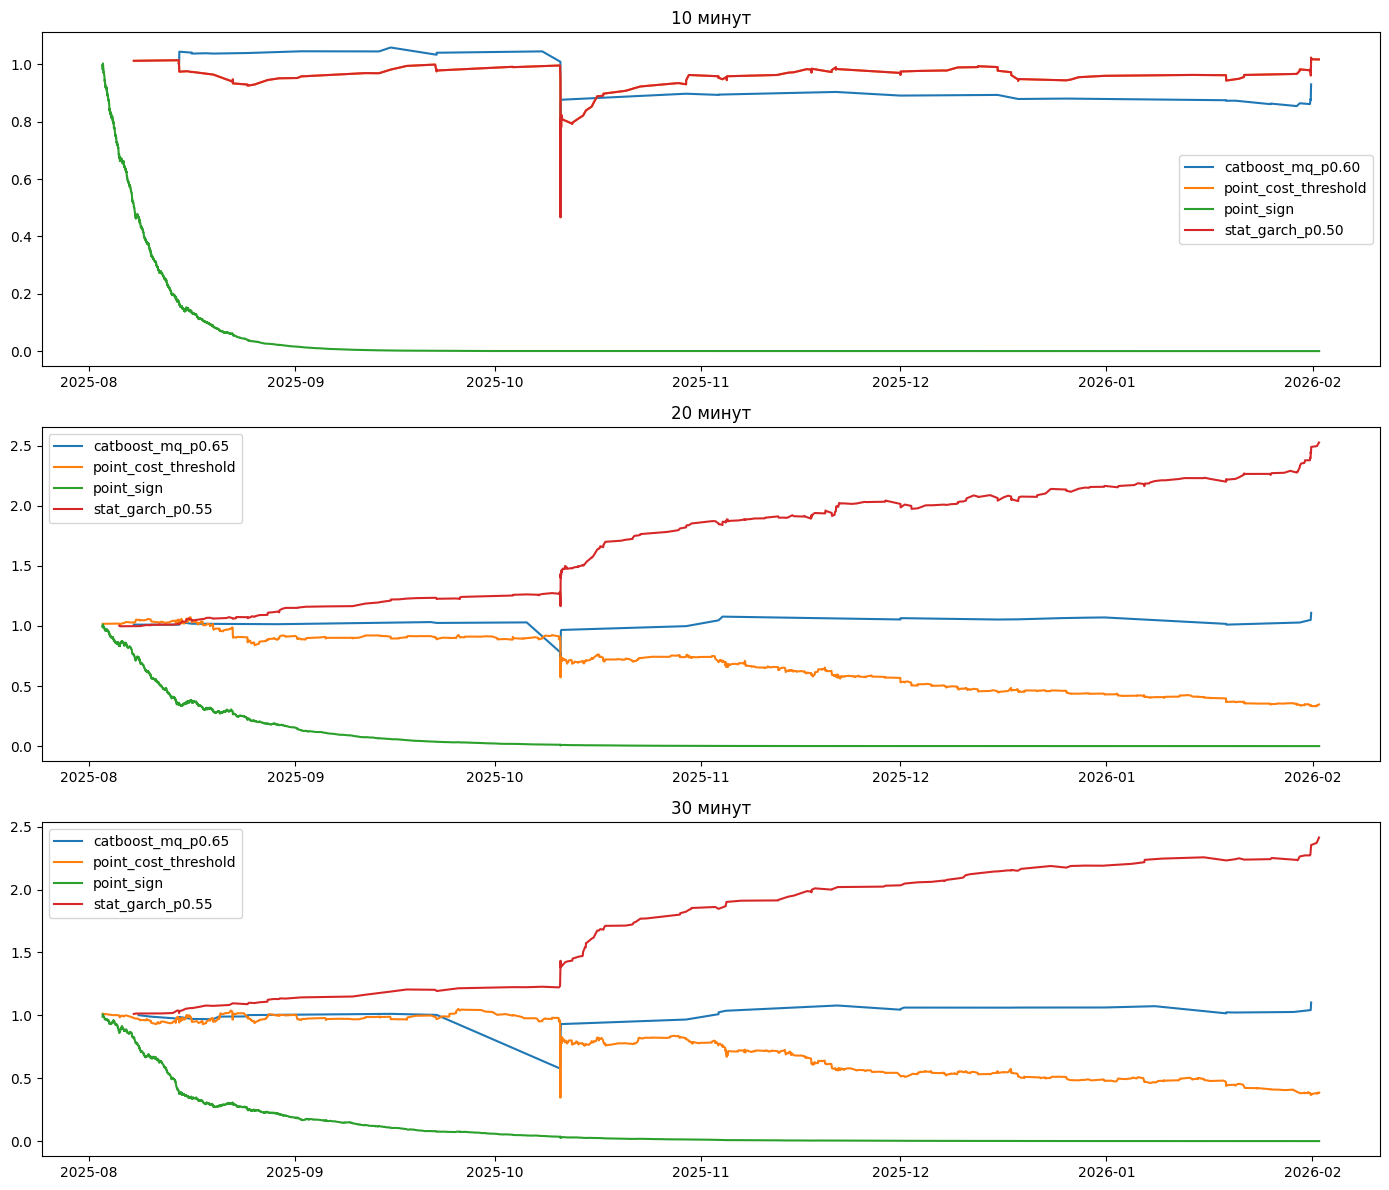

In [5]:
fig, axes = plt.subplots(len(config['horizons']), 1, figsize=(14, 4 * len(config['horizons'])), squeeze=False)
for row, horizon in enumerate(config['horizons']):
    equity = read_parquet(f'{RUN_PREFIX}/horizon_{horizon}/equity.parquet')
    chosen = set(selected.loc[selected.horizon.eq(horizon), 'strategy']) | {'point_sign', 'point_cost_threshold'}
    part = equity[(equity.segment == 'evaluation') & equity.strategy.isin(chosen)].copy()
    for strategy, group in part.groupby('strategy'):
        axes[row, 0].plot(pd.to_datetime(group.exit_timestamp), group.equity, label=strategy)
    axes[row, 0].set_title(f'{horizon} минут')
    axes[row, 0].legend()
plt.tight_layout()

## Интерпретация

Основной вывод следует делать по `evaluation`, а не по `validation`. Положительный результат должен сопровождаться достаточным числом сделок, приемлемой просадкой и устойчивостью к соседним порогам. Тест использует целевую доходность как прокси исполнения и не учитывает проскальзывание и funding.

In [6]:
for horizon in config["horizons"]:
    trades = read_parquet(f"{RUN_PREFIX}/horizon_{horizon}/trades.parquet")

    worst = (
        trades[trades.segment == "evaluation"]
        .sort_values("net_return")
        .head(20)
    )

    print(f"\n{horizon} минут")
    display(worst)


10 минут


,strategy,segment,horizon,entry_timestamp,exit_timestamp,side,gross_return,commission,net_return
36271,point_sign,evaluation,10,2025-10-10 21:10:00+00:00,2025-10-10 21:20:00+00:00,1,-0.614667,0.001,-0.615667
56282,catboost_mq_p0.65,evaluation,10,2025-10-10 21:11:00+00:00,2025-10-10 21:21:00+00:00,1,-0.553902,0.001,-0.554902
53363,stat_garch_p0.50,evaluation,10,2025-10-10 21:12:00+00:00,2025-10-10 21:22:00+00:00,1,-0.486778,0.001,-0.487778
56291,catboost_mq_p0.70,evaluation,10,2025-10-10 21:12:00+00:00,2025-10-10 21:22:00+00:00,1,-0.486778,0.001,-0.487778
55092,catboost_mq_p0.50,evaluation,10,2025-10-10 21:12:00+00:00,2025-10-10 21:22:00+00:00,1,-0.486778,0.001,-0.487778
52981,point_cost_threshold,evaluation,10,2025-10-10 21:12:00+00:00,2025-10-10 21:22:00+00:00,1,-0.486778,0.001,-0.487778
56043,catboost_mq_p0.55,evaluation,10,2025-10-10 21:13:00+00:00,2025-10-10 21:23:00+00:00,1,-0.404861,0.001,-0.405861
56235,catboost_mq_p0.60,evaluation,10,2025-10-10 21:15:00+00:00,2025-10-10 21:25:00+00:00,1,-0.363133,0.001,-0.364133
56234,catboost_mq_p0.60,evaluation,10,2025-10-10 21:05:00+00:00,2025-10-10 21:15:00+00:00,1,-0.127192,0.001,-0.128192
39692,point_sign,evaluation,10,2025-11-03 15:20:00+00:00,2025-11-03 15:30:00+00:00,1,-0.077626,0.001,-0.078626



20 минут


,strategy,segment,horizon,entry_timestamp,exit_timestamp,side,gross_return,commission,net_return
18135,point_sign,evaluation,20,2025-10-10 21:00:00+00:00,2025-10-10 21:20:00+00:00,1,-0.609560,0.001,-0.610560
37640,catboost_mq_p0.70,evaluation,20,2025-10-10 20:58:00+00:00,2025-10-10 21:18:00+00:00,1,-0.406705,0.001,-0.407705
31131,stat_garch_p0.50,evaluation,20,2025-10-10 21:12:00+00:00,2025-10-10 21:32:00+00:00,1,-0.313165,0.001,-0.314165
34257,catboost_mq_p0.50,evaluation,20,2025-10-10 21:12:00+00:00,2025-10-10 21:32:00+00:00,1,-0.313165,0.001,-0.314165
28346,point_cost_threshold,evaluation,20,2025-10-10 21:12:00+00:00,2025-10-10 21:32:00+00:00,1,-0.313165,0.001,-0.314165
36565,catboost_mq_p0.55,evaluation,20,2025-10-10 21:13:00+00:00,2025-10-10 21:33:00+00:00,1,-0.248733,0.001,-0.249733
37534,catboost_mq_p0.65,evaluation,20,2025-10-10 20:56:00+00:00,2025-10-10 21:16:00+00:00,1,-0.242280,0.001,-0.243280
37266,catboost_mq_p0.60,evaluation,20,2025-10-10 21:15:00+00:00,2025-10-10 21:35:00+00:00,1,-0.206329,0.001,-0.207329
37265,catboost_mq_p0.60,evaluation,20,2025-10-10 20:55:00+00:00,2025-10-10 21:15:00+00:00,1,-0.156659,0.001,-0.157659
36564,catboost_mq_p0.55,evaluation,20,2025-10-10 20:53:00+00:00,2025-10-10 21:13:00+00:00,1,-0.110374,0.001,-0.111374



30 минут


,strategy,segment,horizon,entry_timestamp,exit_timestamp,side,gross_return,commission,net_return
21542,stat_garch_p0.50,evaluation,30,2025-10-10 20:50:00+00:00,2025-10-10 21:20:00+00:00,1,-0.639124,0.001,-0.640124
19207,point_cost_threshold,evaluation,30,2025-10-10 20:50:00+00:00,2025-10-10 21:20:00+00:00,1,-0.639124,0.001,-0.640124
25059,catboost_mq_p0.50,evaluation,30,2025-10-10 20:51:00+00:00,2025-10-10 21:21:00+00:00,1,-0.585172,0.001,-0.586172
27156,catboost_mq_p0.55,evaluation,30,2025-10-10 20:52:00+00:00,2025-10-10 21:22:00+00:00,1,-0.529636,0.001,-0.530636
27664,catboost_mq_p0.60,evaluation,30,2025-10-10 20:55:00+00:00,2025-10-10 21:25:00+00:00,1,-0.462904,0.001,-0.463904
27802,catboost_mq_p0.65,evaluation,30,2025-10-10 20:56:00+00:00,2025-10-10 21:26:00+00:00,1,-0.425112,0.001,-0.426112
27849,catboost_mq_p0.70,evaluation,30,2025-10-10 20:59:00+00:00,2025-10-10 21:29:00+00:00,1,-0.357591,0.001,-0.358591
12090,point_sign,evaluation,30,2025-10-10 21:00:00+00:00,2025-10-10 21:30:00+00:00,1,-0.336858,0.001,-0.337858
13230,point_sign,evaluation,30,2025-11-03 15:00:00+00:00,2025-11-03 15:30:00+00:00,1,-0.088985,0.001,-0.089985
16895,point_sign,evaluation,30,2026-01-18 23:30:00+00:00,2026-01-19 00:00:00+00:00,1,-0.059589,0.001,-0.060589


In [7]:
for horizon in config["horizons"]:
    predictions = read_parquet(
        f"{RUN_PREFIX}/horizon_{horizon}/predictions.parquet"
    )

    print(f"\n{horizon} минут")
    display(
        predictions["y_true"]
        .describe(percentiles=[0.001, 0.01, 0.5, 0.99, 0.999])
    )

    print("Максимальная абсолютная простая доходность:")
    print(np.expm1(predictions["y_true"]).abs().max())


10 минут


count    527040.000000
mean         -0.000023
std           0.005249
min          -0.953648
0.1%         -0.023938
1%           -0.010711
50%           0.000000
99%           0.010764
99.9%         0.024068
max           0.529714
Name: y_true, dtype: float64

Максимальная абсолютная простая доходность:
0.698447093396326

20 минут


count    527040.000000
mean         -0.000045
std           0.007169
min          -0.940481
0.1%         -0.033084
1%           -0.015247
50%           0.000000
99%           0.015041
99.9%         0.034462
max           0.590752
Name: y_true, dtype: float64

Максимальная абсолютная простая доходность:
0.8053449804557464

30 минут


count    527040.000000
mean         -0.000067
std           0.008601
min          -1.019221
0.1%         -0.039472
1%           -0.018900
50%           0.000000
99%           0.018435
99.9%         0.042574
max           0.790949
Name: y_true, dtype: float64

Максимальная абсолютная простая доходность:
1.2054894393869824


In [8]:
trades = read_parquet(f"{RUN_PREFIX}/horizon_20/trades.parquet")

display(
    trades[
        (trades.segment == "evaluation") &
        (trades.strategy == "stat_garch_p0.55")
    ]
    .sort_values("net_return")
    .head(20)
)

,strategy,segment,horizon,entry_timestamp,exit_timestamp,side,gross_return,commission,net_return
35824,stat_garch_p0.55,evaluation,20,2025-10-10 21:16:00+00:00,2025-10-10 21:36:00+00:00,1,-0.092639,0.001,-0.093639
35826,stat_garch_p0.55,evaluation,20,2025-10-10 21:56:00+00:00,2025-10-10 22:16:00+00:00,1,-0.024230,0.001,-0.025230
35979,stat_garch_p0.55,evaluation,20,2025-12-01 00:10:00+00:00,2025-12-01 00:30:00+00:00,1,-0.012674,0.001,-0.013674
36014,stat_garch_p0.55,evaluation,20,2025-12-17 16:15:00+00:00,2025-12-17 16:35:00+00:00,1,-0.012189,0.001,-0.013189
36008,stat_garch_p0.55,evaluation,20,2025-12-15 14:57:00+00:00,2025-12-15 15:17:00+00:00,1,-0.010459,0.001,-0.011459
36009,stat_garch_p0.55,evaluation,20,2025-12-15 15:17:00+00:00,2025-12-15 15:37:00+00:00,1,-0.009796,0.001,-0.010796
35832,stat_garch_p0.55,evaluation,20,2025-10-11 02:23:00+00:00,2025-10-11 02:43:00+00:00,-1,-0.009644,0.001,-0.010644
35980,stat_garch_p0.55,evaluation,20,2025-12-01 00:30:00+00:00,2025-12-01 00:50:00+00:00,1,-0.009313,0.001,-0.010313
36059,stat_garch_p0.55,evaluation,20,2026-01-19 00:00:00+00:00,2026-01-19 00:20:00+00:00,1,-0.009131,0.001,-0.010131
35896,stat_garch_p0.55,evaluation,20,2025-11-03 15:27:00+00:00,2025-11-03 15:47:00+00:00,1,-0.009019,0.001,-0.010019


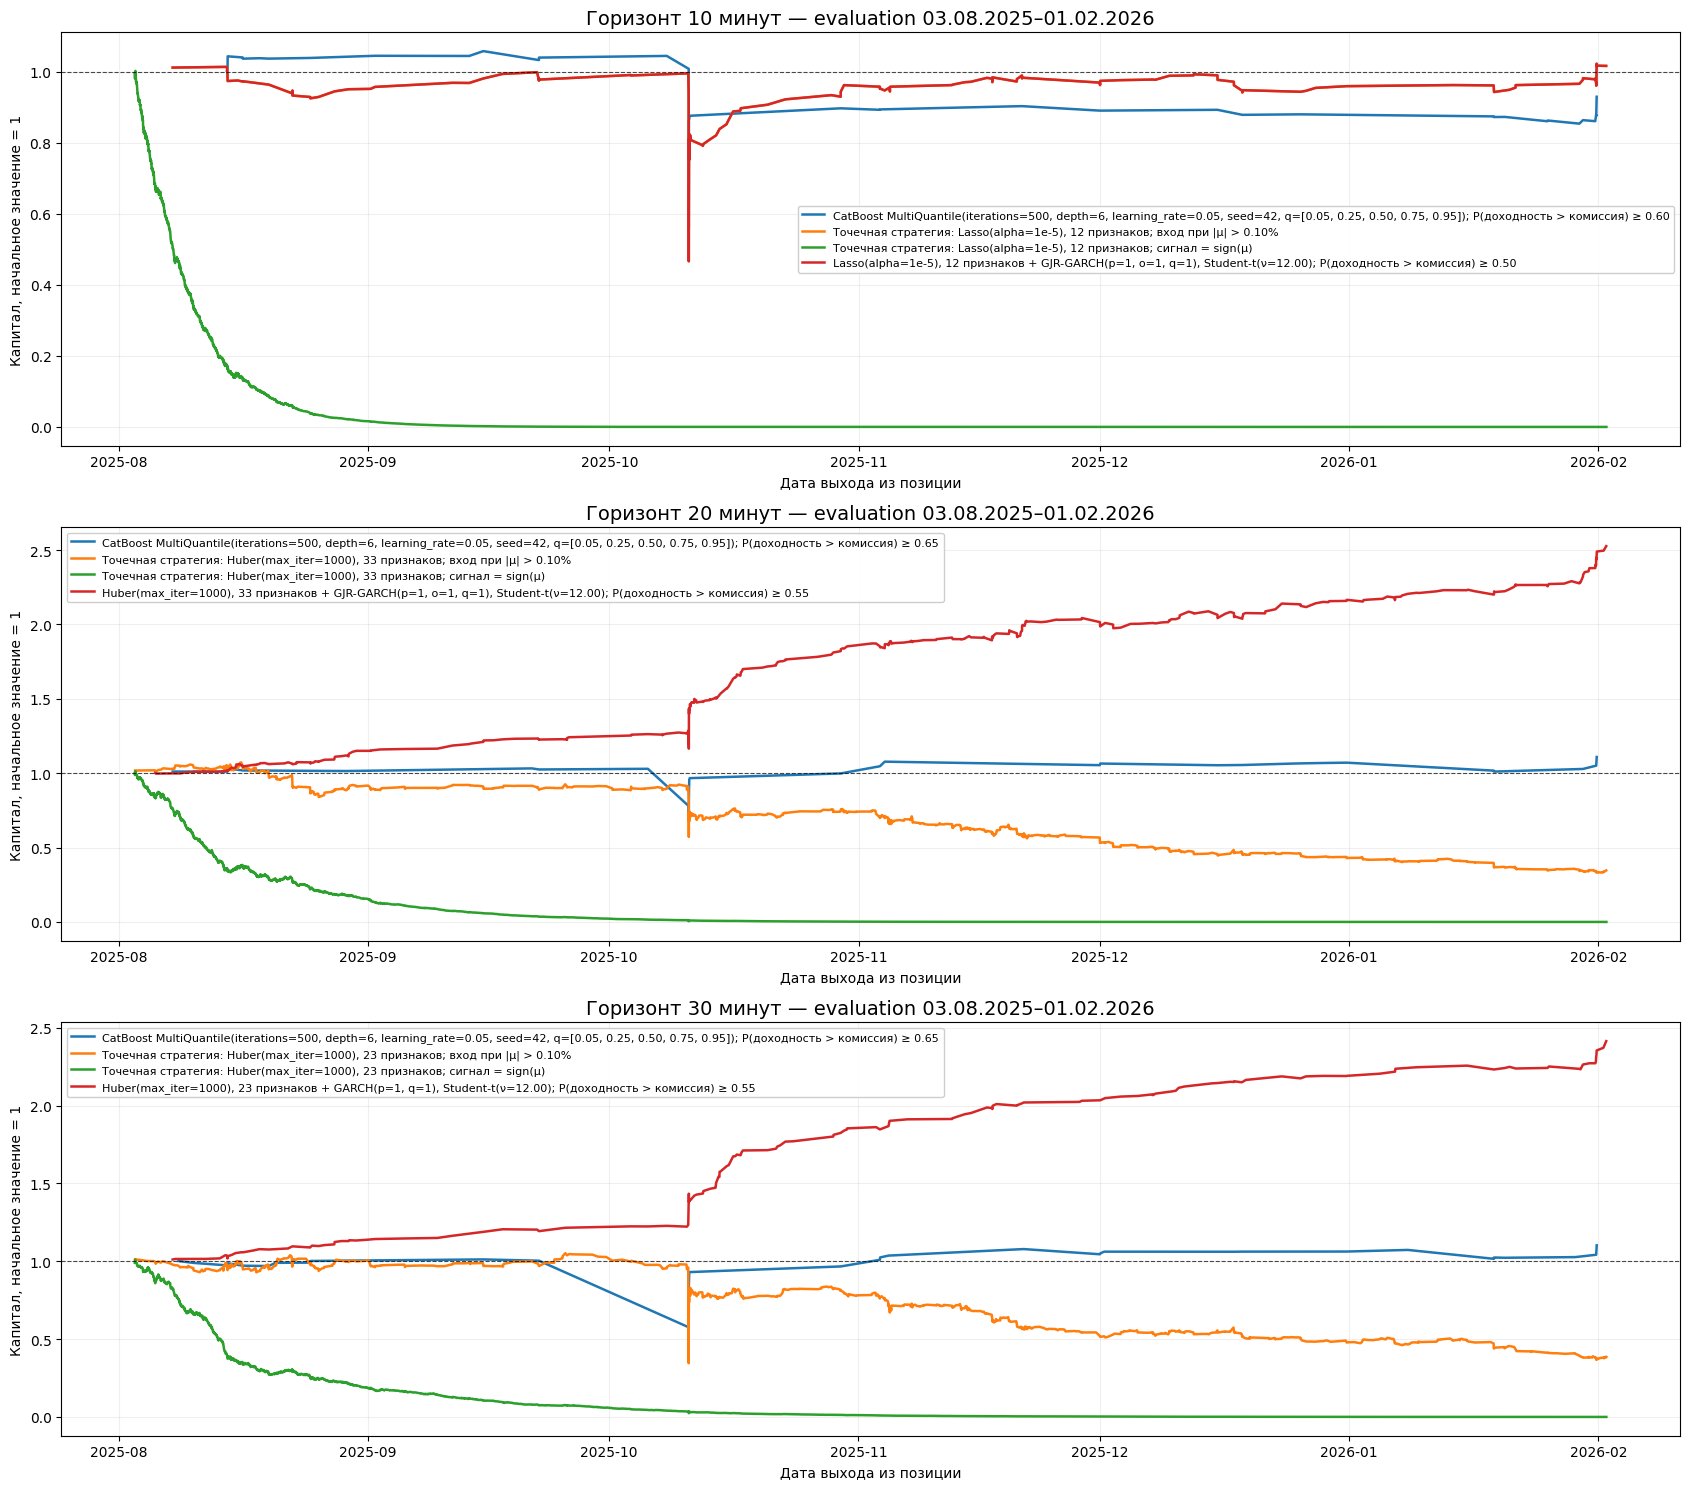

In [9]:
def format_point_model(meta):
    family = str(meta["model_family"])
    n_features = int(meta["n_features"])

    if family == "huber":
        model = "Huber(max_iter=1000)"
    elif family.startswith("lasso_alpha_"):
        alpha = family.removeprefix("lasso_alpha_").replace("_", "-")
        model = f"Lasso(alpha={alpha})"
    elif family.startswith("ridge_alpha_"):
        alpha = family.removeprefix("ridge_alpha_").replace("_", ".")
        model = f"Ridge(alpha={alpha})"
    elif family == "ols":
        model = "OLS"
    else:
        model = family

    return f"{model}, {n_features} признаков"


def format_garch_model(meta):
    name = meta["model_name"]
    p = int(meta["p"])
    o = int(meta["o"])
    q = int(meta["q"])
    nu = float(meta["nu"])

    if name == "gjr_garch_1_1":
        model = f"GJR-GARCH(p={p}, o={o}, q={q})"
    elif name == "garch_1_1":
        model = f"GARCH(p={p}, q={q})"
    else:
        model = f"{name}(p={p}, o={o}, q={q})"

    return f"{model}, Student-t(ν={nu:.2f})"


def format_catboost_model(meta):
    params = meta["params"]

    iterations = params["iterations"]
    depth = params["depth"]
    learning_rate = params["learning_rate"]
    random_seed = params["random_seed"]

    return (
        "CatBoost MultiQuantile"
        f"(iterations={iterations}, depth={depth}, "
        f"learning_rate={learning_rate}, seed={random_seed}, "
        "q=[0.05, 0.25, 0.50, 0.75, 0.95])"
    )


def probability_threshold(strategy):
    return float(strategy.rsplit("_p", 1)[1])


fig, axes = plt.subplots(
    len(config["horizons"]),
    1,
    figsize=(17, 5 * len(config["horizons"])),
    squeeze=False,
)

for row, horizon in enumerate(config["horizons"]):
    horizon_prefix = f"{RUN_PREFIX}/horizon_{horizon}"

    # Загружаем результаты и точные метаданные моделей.
    equity = read_parquet(f"{horizon_prefix}/equity.parquet")

    point_meta = read_json(
        f"{horizon_prefix}/models/point_model_metadata.json"
    )
    garch_meta = read_json(
        f"{horizon_prefix}/models/garch_metadata.json"
    )
    catboost_meta = read_json(
        f"{horizon_prefix}/models/catboost_metadata.json"
    )

    point_description = format_point_model(point_meta)
    garch_description = format_garch_model(garch_meta)
    catboost_description = format_catboost_model(catboost_meta)

    chosen = (
        set(selected.loc[selected.horizon.eq(horizon), "strategy"])
        | {"point_sign", "point_cost_threshold"}
    )

    part = equity[
        equity.segment.eq("evaluation")
        & equity.strategy.isin(chosen)
    ].copy()

    labels = {
        "point_sign": (
            f"Точечная стратегия: {point_description}; "
            "сигнал = sign(μ)"
        ),
        "point_cost_threshold": (
            f"Точечная стратегия: {point_description}; "
            "вход при |μ| > 0.10%"
        ),
    }

    for strategy in chosen:
        if strategy.startswith("stat_garch_p"):
            p = probability_threshold(strategy)
            labels[strategy] = (
                f"{point_description} + {garch_description}; "
                f"P(доходность > комиссия) ≥ {p:.2f}"
            )

        elif strategy.startswith("catboost_mq_p"):
            p = probability_threshold(strategy)
            labels[strategy] = (
                f"{catboost_description}; "
                f"P(доходность > комиссия) ≥ {p:.2f}"
            )

    for strategy, group in part.groupby("strategy"):
        group = group.sort_values("exit_timestamp")

        axes[row, 0].plot(
            pd.to_datetime(group.exit_timestamp),
            group.equity,
            label=labels.get(strategy, strategy),
            linewidth=1.8,
        )

    axes[row, 0].axhline(
        1.0,
        color="black",
        linestyle="--",
        linewidth=0.8,
        alpha=0.7,
    )

    axes[row, 0].set_title(
        f"Горизонт {horizon} минут — evaluation 03.08.2025–01.02.2026",
        fontsize=14,
    )
    axes[row, 0].set_ylabel("Капитал, начальное значение = 1")
    axes[row, 0].set_xlabel("Дата выхода из позиции")
    axes[row, 0].grid(alpha=0.2)

    axes[row, 0].legend(
        fontsize=8,
        loc="best",
        framealpha=0.95,
    )

plt.tight_layout()